# FIG CESM run evaluations

In [1]:
import os
import sys
import yaml
import argparse
import pandas as pd
from glob import glob
from datetime import datetime, timedelta

import numpy as np
import xarray as xr

sys.path.insert(0, os.path.realpath('../libs/'))
import graph_utils as gu
#import verif_utils as vu

In [2]:
import cmaps
# graph tools
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
#import matplotlib.colors as colors
import matplotlib.colors as mcolors
import matplotlib.colorbar as cbar
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
import matplotlib.lines as mlines

from matplotlib.ticker import ScalarFormatter
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import cartopy.crs as ccrs
import cartopy.mpl.geoaxes
import cartopy.feature as cfeature

%matplotlib inline

In [3]:
import matplotlib.transforms as mtransforms

In [4]:
fig_keys = {
    'dpi': 150, 
    'orientation':'portrait', 
    'bbox_inches':'tight', 
    'pad_inches':0.1, 
    'transparent':False
}

In [5]:
need_publish = False

if need_publish:
    dpi_ = fig_keys['dpi']
else:
    dpi_ = 75

In [6]:
EPS = 1e-12
METRICS = ["SEDI", "ETS", "FBIAS", "TS", "POD", "FAR"]


def sedi_from_table(t):
    """Symmetric Extremal Dependence Index (Ferro & Stephenson 2011).
    Half-count continuity correction; NaN with zero hits (undefined, not 0)."""
    hits, miss, fa, cn = (float(x) for x in t)
    n1, n0 = hits + miss, fa + cn
    if n1 <= 0 or n0 <= 0 or hits <= 0:
        return np.nan
    H = min(max(hits / n1, 0.5 / n1), 1.0 - 0.5 / n1)
    F = min(max(fa / n0, 0.5 / n0), 1.0 - 0.5 / n0)
    num = np.log(F) - np.log(H) - np.log(1 - F) + np.log(1 - H)
    den = np.log(F) + np.log(H) + np.log(1 - F) + np.log(1 - H)
    return float(num / den) if abs(den) > EPS else np.nan


def scores_from_table(t):
    hits, miss, fa, cn = (float(x) for x in t)
    n = hits + miss + fa + cn
    hits_r = (hits + miss) * (hits + fa) / (n + EPS)
    den = hits + miss + fa - hits_r
    return dict(SEDI=sedi_from_table(t),
                ETS=(hits - hits_r) / den if den > EPS else np.nan,
                FBIAS=(hits + fa) / (hits + miss + EPS),
                TS=hits / (hits + miss + fa + EPS),
                POD=hits / (hits + miss + EPS),
                FAR=fa / (hits + fa + EPS),
                base_rate=(hits + miss) / (n + EPS))


def fss_from_components(comp):
    comp = np.asarray(comp, float)
    num, den = comp[..., 0], comp[..., 1]
    return np.where(den > EPS, 1.0 - num / np.maximum(den, EPS), np.nan)


def _units(var):
    if "precip" in var.lower():
        return "mm hr$^{-1}$"
    if "spd" in var.lower() or "wind" in var.lower():
        return "m s$^{-1}$"
    return ""


# ---- schema-robust reader: sums over the per-storm axis if the file has one,
# so the SAME code runs on the pre-pooled corrdiff_pmm_ingredients_hourly.nc
# AND on the diagnosed, per-storm tc_extreme_ingredients.nc ----
def _pool(ds, name, v):
    da = ds[name]
    sdim = f"{v}_storm"
    if sdim in da.dims:
        da = da.sum(sdim)
    return np.asarray(da.values, float)


def _has_unet(ds, v):
    return bool(int(ds.attrs.get("has_unet", 0))) or (f"{v}_unet_tables" in ds)


def _member_metric_array(ds, v, ens, ti, metric):
    """Per-member array of a table metric at threshold index ti -> (M,)."""
    mt = _pool(ds, f"{v}_{ens}_member_tables", v)[ti]            # (M, 4)
    return np.array([scores_from_table(mt[m])[metric]
                     for m in range(mt.shape[0])])


def _pmm_metric(ds, v, ens, ti, metric):
    return scores_from_table(_pool(ds, f"{v}_{ens}_pmm_tables", v)[ti])[metric]


def _unet_metric(ds, v, ti, metric):
    return scores_from_table(_pool(ds, f"{v}_unet_tables", v)[ti])[metric]


def _base_rate(ds, v, ens, ti):
    """Base rate at threshold ti (identical across sources on the common mask)."""
    return scores_from_table(_pool(ds, f"{v}_{ens}_pmm_tables", v)[ti])["base_rate"]


def _member_fss_array(ds, v, ens, ti, si):
    """Per-member FSS at threshold ti, scale index si -> (M,)."""
    comp = _pool(ds, f"{v}_{ens}_member_fss", v)[ti, :, si, :]   # (M, 2)
    return fss_from_components(comp)


def _pmm_fss(ds, v, ens, ti, si):
    return fss_from_components(_pool(ds, f"{v}_{ens}_pmm_fss", v)[ti, si, :])


def _unet_fss(ds, v, ti, si):
    return fss_from_components(_pool(ds, f"{v}_unet_fss", v)[ti, si, :])

fn = '/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_TC/verif_hourly/tc_extreme_ingredients.nc'
ds = xr.open_dataset(fn).load()                 # .load(): everything in memory

ensembles = list(np.atleast_1d(ds.attrs["ensembles"]))
variables = list(np.atleast_1d(ds.attrs["variables"]))

dict_PLOT = {}
for v in ['WRF_precip', 'WRF_SPD10']:
    thr = ds[f"{v}_thr"].values
    scales = ds[f"{v}_scale"].values
    nthr = thr.size
    has_u = _has_unet(ds, v)

    dict_PLOT[v] = {}
    P = dict_PLOT[v]
    P['thres'] = thr
    P['scales'] = scales
    P['base_rate'] = np.array([_base_rate(ds, v, ensembles[0], ti)
                               for ti in range(nthr)])

    # ---- table metrics: members (mean/lo/hi), PMM, UNET ----
    for metric in METRICS:
        for ens in ensembles:
            mm = np.array([_member_metric_array(ds, v, ens, ti, metric)
                           for ti in range(nthr)])              # (nthr, M)
            P[f'{metric}_{ens}_members_mean'] = np.nanmean(mm, axis=1)
            P[f'{metric}_{ens}_members_lo'] = np.nanmin(mm, axis=1)
            P[f'{metric}_{ens}_members_hi'] = np.nanmax(mm, axis=1)
            P[f'{metric}_{ens}_PMM'] = np.array([_pmm_metric(ds, v, ens, ti, metric) for ti in range(nthr)])
        if has_u:
            P[f'{metric}_UNET'] = np.array([_unet_metric(ds, v, ti, metric) for ti in range(nthr)])

    # ---- FSS: per threshold, at each scale (key is FSS{scale}) ----
    for si, s in enumerate(scales):
        s = int(s)
        for ens in ensembles:
            ff = np.array([_member_fss_array(ds, v, ens, ti, si)
                           for ti in range(nthr)])              # (nthr, M)
            P[f'FSS{s}_{ens}_members_mean'] = np.nanmean(ff, axis=1)
            P[f'FSS{s}_{ens}_members_lo'] = np.nanmin(ff, axis=1)
            P[f'FSS{s}_{ens}_members_hi'] = np.nanmax(ff, axis=1)
            P[f'FSS{s}_{ens}_PMM'] = np.array([_pmm_fss(ds, v, ens, ti, si) for ti in range(nthr)])
        if has_u:
            P[f'FSS{s}_UNET'] = np.array([_unet_fss(ds, v, ti, si) for ti in range(nthr)])

In [7]:
N_BOOT = 1000 # <------- boostrapping
BOOT_SEED = 777


def _per_storm(ds, v, name):
    """storm axis first, remaining dims in file order; none if already pooled"""
    if name not in ds:
        return None
    da = ds[name]
    sdim = f"{v}_storm"
    if sdim not in da.dims:
        return None
    rest = [d for d in da.dims if d != sdim]
    return np.asarray(da.transpose(sdim, *rest).values, float)


def _scores_vec(tab):
    """tab (..., 4) -> dict of (...) arrays; mirrors scores_from_table exactly"""
    h, m, f, c = (tab[..., i] for i in range(4))
    n = h + m + f + c
    n1, n0 = h + m, f + c
    with np.errstate(divide='ignore', invalid='ignore'):
        hr = n1 * (h + f) / (n + EPS)
        den = h + m + f - hr
        ets = np.where(den > EPS, (h - hr) / np.where(den > EPS, den, 1.0), np.nan)

        s1 = np.where(n1 > 0, n1, 1.0)
        s0 = np.where(n0 > 0, n0, 1.0)
        H = np.clip(h / s1, 0.5 / s1, 1.0 - 0.5 / s1)
        F = np.clip(f / s0, 0.5 / s0, 1.0 - 0.5 / s0)
        s_num = np.log(F) - np.log(H) - np.log(1 - F) + np.log(1 - H)
        s_den = np.log(F) + np.log(H) + np.log(1 - F) + np.log(1 - H)
        ok = (n1 > 0) & (n0 > 0) & (h > 0) & (np.abs(s_den) > EPS)
        sedi = np.where(ok, s_num / np.where(np.abs(s_den) > EPS, s_den, 1.0), np.nan)

    return dict(SEDI=sedi, ETS=ets,
                FBIAS=(h + f) / (h + m + EPS),
                TS=h / (h + m + f + EPS),
                POD=h / (h + m + EPS),
                FAR=f / (h + f + EPS),
                base_rate=n1 / (n + EPS))


# one shared resample, reused for every metric / threshold / source so the
# intervals are mutually coherent rather than independently noisy
_n_storm = None
for v in ['WRF_precip', 'WRF_SPD10']:
    sdim = f"{v}_storm"
    if sdim in ds.dims:
        _n_storm = int(ds.sizes[sdim])
        break

if _n_storm is None:
    BOOT_IDX = None
    print('no per-storm axis in this file -> bootstrap unavailable, '
          'box will fall back to the member distribution')
else:
    BOOT_IDX = np.random.default_rng(BOOT_SEED).integers(
        0, _n_storm, size=(N_BOOT, _n_storm))
    print('storm-level bootstrap: n_storm={}  n_boot={}'.format(_n_storm, N_BOOT))


def _boot_from_tables(tab_storm, metric, chunk=200):
    """(n_storm, nthr, 4) -> (n_boot, nthr); chunked to bound peak memory"""
    out = np.empty((BOOT_IDX.shape[0], tab_storm.shape[1]), float)
    for a in range(0, BOOT_IDX.shape[0], chunk):
        b = min(a + chunk, BOOT_IDX.shape[0])
        pooled = tab_storm[BOOT_IDX[a:b]].sum(axis=1)      # (chunk, nthr, 4)
        out[a:b] = _scores_vec(pooled)[metric]
    return out


def _boot_from_fss(comp_storm, si, chunk=200):
    """(n_storm, nthr, nscale, 2) -> (n_boot, nthr); components are additive"""
    comp = comp_storm[:, :, si, :]                          # (n_storm, nthr, 2)
    out = np.empty((BOOT_IDX.shape[0], comp.shape[1]), float)
    for a in range(0, BOOT_IDX.shape[0], chunk):
        b = min(a + chunk, BOOT_IDX.shape[0])
        pooled = comp[BOOT_IDX[a:b]].sum(axis=1)            # (chunk, nthr, 2)
        num, den = pooled[..., 0], pooled[..., 1]
        out[a:b] = np.where(den > EPS, 1.0 - num / np.maximum(den, EPS), np.nan)
    return out


# ---- store full member arrays + bootstrap draws alongside the existing keys -
for v in ['WRF_precip', 'WRF_SPD10']:
    P = dict_PLOT[v]
    thr = ds[f"{v}_thr"].values
    scales = ds[f"{v}_scale"].values
    nthr = thr.size
    has_u = _has_unet(ds, v)

    for metric in METRICS:
        for ens in ensembles:
            P[f'{metric}_{ens}_members'] = np.array(
                [_member_metric_array(ds, v, ens, ti, metric) for ti in range(nthr)])
            if BOOT_IDX is not None:
                t = _per_storm(ds, v, f"{v}_{ens}_pmm_tables")
                if t is not None:
                    P[f'{metric}_{ens}_PMM_boot'] = _boot_from_tables(t, metric)
        if has_u and BOOT_IDX is not None:
            t = _per_storm(ds, v, f"{v}_unet_tables")
            if t is not None:
                P[f'{metric}_UNET_boot'] = _boot_from_tables(t, metric)

    for si, s in enumerate(scales):
        s = int(s)
        for ens in ensembles:
            P[f'FSS{s}_{ens}_members'] = np.array(
                [_member_fss_array(ds, v, ens, ti, si) for ti in range(nthr)])
            if BOOT_IDX is not None:
                cf = _per_storm(ds, v, f"{v}_{ens}_pmm_fss")
                if cf is not None:
                    P[f'FSS{s}_{ens}_PMM_boot'] = _boot_from_fss(cf, si)
        if has_u and BOOT_IDX is not None:
            cf = _per_storm(ds, v, f"{v}_unet_fss")
            if cf is not None:
                P[f'FSS{s}_UNET_boot'] = _boot_from_fss(cf, si)

# ---- resolve the figure's model labels against the file's ensemble names ---
_lut = {e.lower(): e for e in ensembles}
MODEL_TO_ENS = {'ERA5': _lut.get('era5', ensembles[0]),
                'GDAS': _lut.get('gdas', ensembles[-1])}
print('model -> ensemble key:', MODEL_TO_ENS)

storm-level bootstrap: n_storm=25  n_boot=1000
model -> ensemble key: {'ERA5': 'ERA5', 'GDAS': 'GDAS'}


In [8]:
fn = '/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_TC/verif_hourly/reliability_PLOT.npy'
dict_PLOT_REL = np.load(fn, allow_pickle=True)[()]

In [9]:
my_colors = gu.ksha_color_set_summon(color_set=0)
cyan = my_colors['cyan']
blue = my_colors['blue']
red = my_colors['red']
orange = my_colors['orange']

In [10]:
line_keys = {}
line_keys['UNET'] = {'linewidth': 3, 'linestyle': '--', 'color': blue, 'alpha': 1, 'zorder': 3, 'label': ''}
line_keys['ERA5'] = {'linewidth': 3, 'linestyle': '--', 'color': red, 'alpha': 1, 'zorder': 4, 'label': ''}
line_keys['GDAS'] = {'linewidth': 3, 'linestyle': '-', 'color': orange, 'alpha': 1, 'zorder': 2, 'label': ''}
line_keys['target'] = {'linewidth': 2.5, 'linestyle': '--', 'color': 'k', 'alpha': 1, 'zorder': 1, 'label': ''}

## Plot

In [11]:
from matplotlib.collections import LineCollection
import matplotlib.ticker as mticker
from scipy.stats import gaussian_kde

def _rgb2hex(rgb):
    """convert np.array rgb/rgba (0-1 float) to hex string."""
    return mcolors.to_hex(np.asarray(rgb)[:3])

_red    = _rgb2hex(red)
_orange = _rgb2hex(orange)
_blue   = _rgb2hex(blue)

VIOLIN_SOURCE = 'boot' if BOOT_IDX is not None else 'members'

MIN_KDE_N = 30        # below this, strip plot instead of kde
KDE_BW = 'scott'      # or a float; smaller = less smoothing
KDE_GRID = 160
VIOLIN_WIDTH = 0.21   # dodge spacing is 0.25, leaves a 0.04 gutter
CLIP_TO_SUPPORT = True   # evaluate kde only over [min, max] of the draws

_MARK = 10.0
_EDGE = 1.0
_MED_LW = 0.5

# ── Style Dictionaries ───────────────────────────────────────
violin_styles = {
    'ERA5': dict(marker='s', color=_red,    zorder=4, label='ERA5'),
    'GDAS': dict(marker='s', color=_orange, zorder=2, label='GDAS'),
    'UNET': dict(marker='s', color=_blue,   zorder=3, label='UNET'),
}

model_order = ['ERA5', 'GDAS', 'UNET']

_dodge_offsets = {
    'ERA5': -0.25,
    'GDAS':  0.00,
    'UNET': +0.25,
}

In [ ]:
def _get_samples(P, metric, model):
    """(nthr, n_sample) draws, plus a tag naming what they are"""
    if model == 'UNET':
        k = f'{metric}_UNET_boot'
        if VIOLIN_SOURCE == 'boot' and k in P:
            return P[k].T, 'boot'
        return None, 'none'

    ens = MODEL_TO_ENS[model]
    if VIOLIN_SOURCE == 'boot':
        k = f'{metric}_{ens}_PMM_boot'
        if k in P:
            return P[k].T, 'boot'
    k = f'{metric}_{ens}_members'
    if k in P:
        return P[k], 'members'
    return None, 'none'


def _get_point(P, metric, model):
    """single value to fall back on when no distribution exists"""
    if model == 'UNET':
        return P.get(f'{metric}_UNET')
    ens = MODEL_TO_ENS[model]
    for k in (f'{metric}_{ens}_PMM', f'{metric}_{ens}_members_mean'):
        if k in P:
            return P[k]
    return None


def _note_span(ax, vals):
    vals = np.asarray(vals, float).ravel()
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return
    prev = getattr(ax, '_v_span', [np.inf, -np.inf])
    ax._v_span = [min(prev[0], float(vals.min())),
                  max(prev[1], float(vals.max()))]


def _one_violin(ax, xi, s, style, width, bw=KDE_BW):
    lo, hi = float(s.min()), float(s.max())
    grid = np.linspace(lo, hi, KDE_GRID) if CLIP_TO_SUPPORT else \
        np.linspace(lo - 0.05 * (hi - lo), hi + 0.05 * (hi - lo), KDE_GRID)

    try:
        dens = gaussian_kde(s, bw_method=bw)(grid)
    except Exception:
        return False                       # singular covariance -> caller falls back

    if not np.isfinite(dens).any() or dens.max() <= 0:
        return False

    half = 0.5 * width * dens / dens.max()
    ax.fill_betweenx(grid, xi - half, xi + half,
                     facecolor=style['color'], edgecolor=style['color'],
                     linewidth=_EDGE, zorder=style['zorder'])

    med = float(np.median(s))
    w_at_med = np.interp(med, grid, half)
    ax.plot([xi - w_at_med, xi + w_at_med], [med, med],
            color='k', linewidth=_MED_LW, solid_capstyle='butt',
            zorder=style['zorder'] + 0.1)
    return True


def _draw_dist(ax, x, samples, style, width=VIOLIN_WIDTH, verbose=False):
    """
    violin where n supports a kde, strip of raw points where it does not,
    marker where the position is degenerate, nothing where all draws are nan.
    """
    x = np.asarray(x, float)
    n_violin = n_strip = n_point = n_empty = 0
    strip_x, strip_y, pt_x, pt_y = [], [], [], []
    n_finite = []

    for xi, s in zip(x, samples):
        s = np.asarray(s, float)
        s = s[np.isfinite(s)]
        n_finite.append(s.size)

        if s.size == 0:
            n_empty += 1
            continue
        if s.size < 3 or np.ptp(s) <= 0:
            pt_x.append(xi); pt_y.append(float(np.median(s)))
            n_point += 1
            continue

        if s.size >= MIN_KDE_N:
            if _one_violin(ax, xi, s, style, width):
                _note_span(ax, s)
                n_violin += 1
                continue
        # small n: show the actual values, jittered, rather than a fake curve
        jit = np.linspace(-0.3 * width, 0.3 * width, s.size)
        strip_x.append(xi + jit); strip_y.append(np.sort(s))
        pt_x.append(xi); pt_y.append(float(np.median(s)))
        _note_span(ax, s)
        n_strip += 1

    if strip_x:
        ax.plot(np.concatenate(strip_x), np.concatenate(strip_y),
                linestyle='none', marker='o', markersize=3.0,
                markerfacecolor=style['color'], markeredgecolor='k',
                markeredgewidth=0.4, alpha=0.85, zorder=style['zorder'])

    if pt_x:
        ax.plot(pt_x, pt_y, linestyle='none', marker=style['marker'],
                markersize=_MARK, markerfacecolor=style['color'],
                markeredgecolor='k', markeredgewidth=_EDGE,
                zorder=style['zorder'] + 0.2)
        _note_span(ax, pt_y)

def _draw_point(ax, x, y, style):
    y = np.asarray(y, float)
    ax.plot(np.asarray(x, float), y, linestyle='none', marker=style['marker'],
            markersize=_MARK, markerfacecolor=style['color'],
            markeredgecolor='k', markeredgewidth=_EDGE,
            zorder=style['zorder'])
    _note_span(ax, y)


def _fit_ylim(ax, pad_frac=0.06, floor=None, ceil=None, nbins=5):
    """
    tighten to the drawn range. this supersedes the hardcoded set_ylim /
    set_yticks for the score panels, which were tuned for the old stems and
    waste roughly a third of the vertical range.
    """
    if not hasattr(ax, '_v_span'):
        return
    s0, s1 = ax._v_span
    if not (np.isfinite(s0) and np.isfinite(s1)):
        return
    rng = max(s1 - s0, 1e-6)
    y0, y1 = s0 - pad_frac * rng, s1 + pad_frac * rng
    if floor is not None:
        y0 = max(y0, floor)
    if ceil is not None:
        y1 = min(y1, ceil)
    ax.set_ylim([y0, y1])
    ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=nbins))


def _fill_score_panels(AX, var_key, xlabel, metrics, bounds, verbose=True):
    """shared body for the precip and wind score rows"""
    P = dict_PLOT[var_key]
    fake_x = np.arange(len(P['thres']))

    for i_ax, metric in enumerate(metrics):
        ax = AX[i_ax]
        for model in model_order:
            sty = violin_styles[model]
            x_shifted = fake_x + _dodge_offsets[model]

            samples, tag = _get_samples(P, metric, model)
            if samples is None:
                pt = _get_point(P, metric, model)
                if pt is not None:
                    _draw_point(ax, x_shifted, pt, sty)
                continue
            _draw_dist(ax, x_shifted, samples, sty, verbose=verbose)

        ax.set_xticks(fake_x)
        ax.set_xticklabels(P['thres'], fontsize=14)
        pad = max(abs(v) for v in _dodge_offsets.values()) + 0.3
        ax.set_xlim(fake_x[0] - pad, fake_x[-1] + pad)
        ax.set_xlabel(xlabel, fontsize=14)

        floor, ceil = bounds[i_ax]
        _fit_ylim(ax, floor=floor, ceil=ceil)

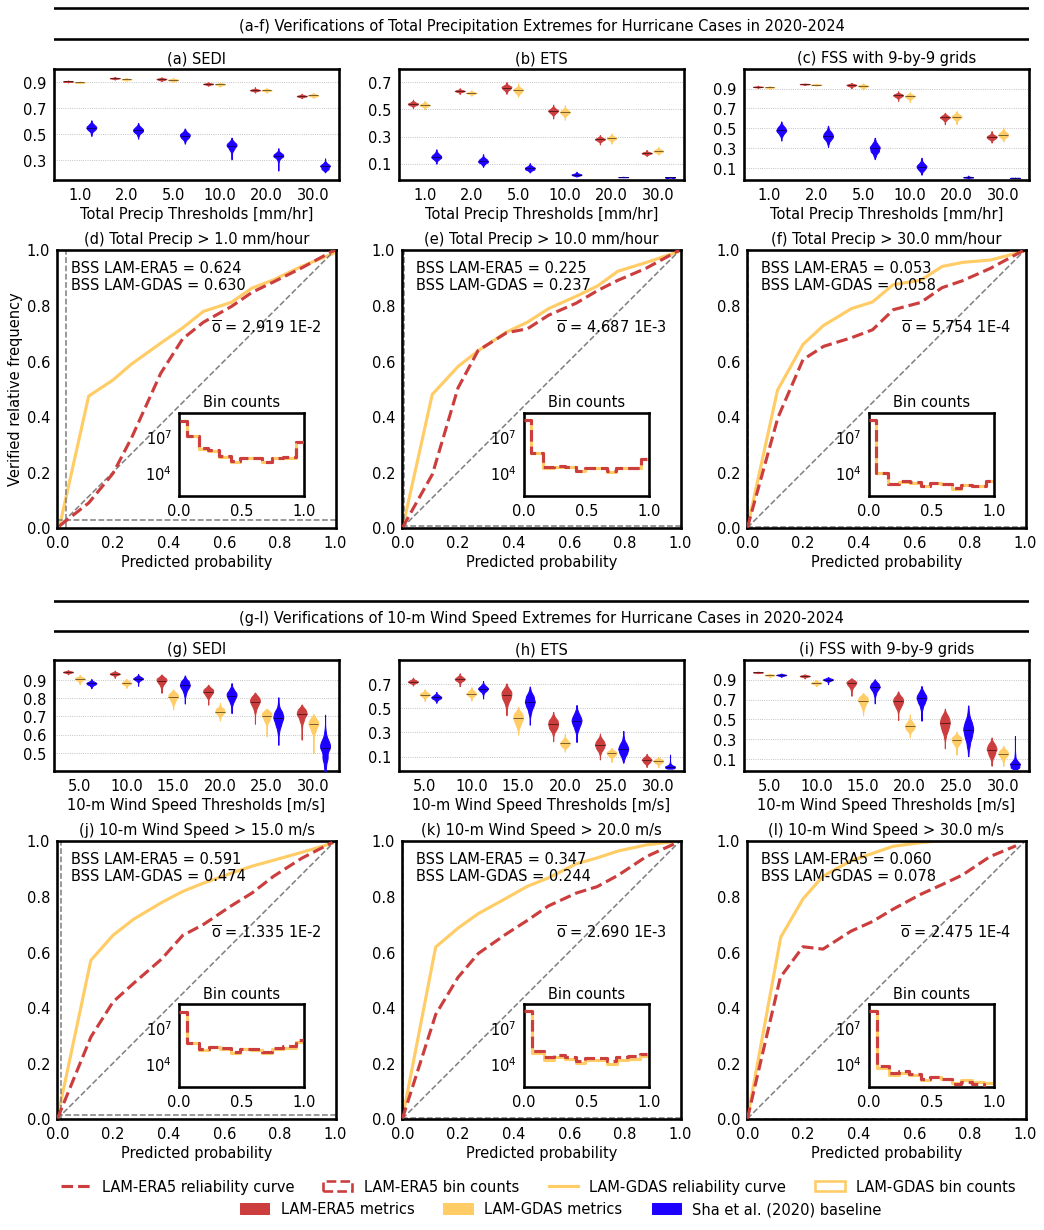

In [12]:
for v in ['WRF_precip', 'WRF_SPD10']:
    for model in model_order:
        s, tag = _get_samples(dict_PLOT[v], 'SEDI', model)

fig = plt.figure(figsize=(13, 14), dpi=dpi_)
gs = gridspec.GridSpec(7, 3, height_ratios=[0.4, 0.25, 1, 0.475, 0.4, 0.25, 1], width_ratios=[1, 1, 1])

AX_ETS_p, AX_REL_p, AX_ETS_w, AX_REL_w = [], [], [], []
for i in range(3):
    AX_ETS_p.append(plt.subplot(gs[0, i]))
    AX_REL_p.append(plt.subplot(gs[2, i]))
    AX_ETS_w.append(plt.subplot(gs[4, i]))
    AX_REL_w.append(plt.subplot(gs[6, i]))

AX_all = AX_ETS_p + AX_REL_p + AX_ETS_w + AX_REL_w
for ax in AX_all:
    gu.ax_decorate_box(ax)
for ax in AX_REL_p + AX_REL_w:
    ax.set_aspect('equal')
    ax.set_xlabel('Predicted probability', fontsize=14)

AX_REL_p[0].set_title('(d) Total Precip > 1.0 mm/hour', fontsize=14)
AX_REL_p[1].set_title('(e) Total Precip > 10.0 mm/hour', fontsize=14)
AX_REL_p[2].set_title('(f) Total Precip > 30.0 mm/hour', fontsize=14)
AX_REL_p[0].set_ylabel('Verified relative frequency', fontsize=14)

AX_REL_w[0].set_title('(j) 10-m Wind Speed > 15.0 m/s', fontsize=14)
AX_REL_w[1].set_title('(k) 10-m Wind Speed > 20.0 m/s', fontsize=14)
AX_REL_w[2].set_title('(l) 10-m Wind Speed > 30.0 m/s', fontsize=14)


for ax in AX_ETS_p+AX_ETS_w:
    ax.tick_params(labelleft=True, labelbottom=True, labelsize=14)
    ax.grid(axis='y', linestyle=':')
    ax.set_axisbelow(True)  # keep the y grid behind the violins

for ax in AX_REL_p+AX_REL_w:
    ax.set_xlim([0, 1.0])
    ax.set_ylim([0, 1.0])
    ax.tick_params(labelbottom=True, labelleft=True)

# score-panel ylim / yticks are now set by _fit_ylim; only titles here
AX_ETS_p[0].set_title('(a) SEDI', fontsize=14)
AX_ETS_p[1].set_title('(b) ETS', fontsize=14)
AX_ETS_p[2].set_title('(c) FSS with 9-by-9 grids', fontsize=14)

plt.subplots_adjust(0, 0, 1, 1, hspace=0.0, wspace=0.21)

# ================================================= #
# WRF_precip Scores
# ================================================= #

_scales_p = list(dict_PLOT['WRF_precip']['scales'])
_fss_key = 'FSS{}'.format(int(_scales_p[_scales_p.index(9)] if 9 in _scales_p
                              else _scales_p[0]))

_fill_score_panels(
    AX_ETS_p, 'WRF_precip', 'Total Precip Thresholds [mm/hr]',
    ['SEDI', 'ETS', _fss_key],
    [(0.0, 1.0), (0.0, None), (0.0, 1.0)],
)

AX_ETS_p[0].set_ylim([0.15, 1.0])
AX_ETS_p[0].set_yticks([0.3, 0.5, 0.7, 0.9])

AX_ETS_p[1].set_ylim([-0.02, 0.8])
AX_ETS_p[1].set_yticks([0.1, 0.3, 0.5, 0.7])

AX_ETS_p[2].set_ylim([-0.02, 1.1])
AX_ETS_p[2].set_yticks([0.1, 0.3, 0.5, 0.7, 0.9])

# ================================================= #
# WRF_precip Reliability
# ================================================= #
f = [1e2, 1e3, 1e4]
ref_x = np.linspace(0, 1, 50)
for i_ax, ax in enumerate(AX_REL_p):
    var_ = 'WRF_precip'
    f_ = f[i_ax]
    if f_ == 1e2:
        scale_ = '1E-2'
    elif f_ == 1e3:
        scale_ = '1E-3'
    elif f_ == 1e4:
        scale_ = '1E-4'

    key_ = f'era5_thresID_{i_ax}'
    mean_prob = dict_PLOT_REL[var_][key_]['mean_prob']
    obs_freq = dict_PLOT_REL[var_][key_]['obs_freq']
    ax.plot(mean_prob, obs_freq, **line_keys['ERA5'])

    bss = dict_PLOT_REL[var_][key_]['bss']
    ax.text(
        0.05, 0.96, f'BSS LAM-ERA5 = {bss:.3f}',
        fontsize=14, ha='left', va='top', transform=ax.transAxes
    )

    key_ = f'gdas_thresID_{i_ax}'
    mean_prob = dict_PLOT_REL[var_][key_]['mean_prob']
    obs_freq = dict_PLOT_REL[var_][key_]['obs_freq']
    ax.plot(mean_prob, obs_freq, **line_keys['GDAS'])

    bss = dict_PLOT_REL[var_][key_]['bss']
    ax.text(
        0.05, 0.9, f'BSS LAM-GDAS = {bss:.3f}',
        fontsize=14, ha='left', va='top', transform=ax.transAxes
    )

    ax.plot(ref_x, ref_x, linestyle='--', linewidth=1.5, color='0.5')

    o_bar = dict_PLOT_REL[var_][key_]['base_rate']
    ax.hlines(o_bar, xmin=0, xmax=1.0, linestyle='--', linewidth=1.5, color='0.5')
    ax.vlines(o_bar, ymin=0, ymax=1.0, linestyle='--', linewidth=1.5, color='0.5')
    ax.text(
        0.95, 0.75, r'$\mathsf{\overline{o}}$' + f' = {f[i_ax]*o_bar:.3f}' + f' {scale_}',
        fontsize=14, ha='right', va='top', transform=ax.transAxes
    )

    # =================================================================
    # Bin count sub-axis (log-scale histogram overlay)
    # =================================================================
    ax_sub = inset_axes(
        ax,
        width="45%",
        height="30%",
        loc='lower right',
        borderpad=3
    )

    ax_sub = gu.ax_decorate_box(ax_sub)
    ax_sub.set_yscale('log')
    ax_sub.set_xlim([0, 1])
    ax_sub.set_ylim([1e2, 1e9])
    ax_sub.set_yticks([1e4, 1e7])
    ax_sub.tick_params(labelbottom=True, labelleft=True)
    ax_sub.set_title('Bin counts', fontsize=14)

    # ERA5 bin counts
    key_ = f'era5_thresID_{i_ax}'
    mp = dict_PLOT_REL[var_][key_]['mean_prob']
    bc = dict_PLOT_REL[var_][key_]['counts']
    valid = bc > 0  # filter empty bins to avoid log(0)
    ax_sub.step(mp[valid], bc[valid], where='mid', **line_keys['ERA5'])

    # GDAS bin counts
    key_ = f'gdas_thresID_{i_ax}'
    mp = dict_PLOT_REL[var_][key_]['mean_prob']
    bc = dict_PLOT_REL[var_][key_]['counts']
    valid = bc > 0
    ax_sub.step(mp[valid], bc[valid], where='mid', **line_keys['GDAS'])

# ================================================= #
# WRF_SPD10 Scores
# ================================================= #
AX_ETS_w[0].set_title('(g) SEDI', fontsize=14)
AX_ETS_w[1].set_title('(h) ETS', fontsize=14)
AX_ETS_w[2].set_title('(i) FSS with 9-by-9 grids', fontsize=14)

_scales_w = list(dict_PLOT['WRF_SPD10']['scales'])
_fss_key_w = 'FSS{}'.format(int(_scales_w[_scales_w.index(9)] if 9 in _scales_w
                                else _scales_w[0]))

_fill_score_panels(
    AX_ETS_w, 'WRF_SPD10', '10-m Wind Speed Thresholds [m/s]',
    ['SEDI', 'ETS', _fss_key_w],
    [(0.0, 1.0), (0.0, None), (0.0, 1.0)],
)

AX_ETS_w[0].set_ylim([0.4, 1.01])
AX_ETS_w[0].set_yticks([0.5, 0.6, 0.7, 0.8, 0.9])

AX_ETS_w[1].set_ylim([-0.02, 0.9])
AX_ETS_w[1].set_yticks([0.1, 0.3, 0.5, 0.7,])

AX_ETS_w[2].set_ylim([-0.02, 1.1])
AX_ETS_w[2].set_yticks([0.1, 0.3, 0.5, 0.7, 0.9])

# ================================================= #
# WRF_SPD10 Reliability
# ================================================= #
f = [1e2, 1e3, 1e4]
ref_x = np.linspace(0, 1, 50)
for i_ax, ax in enumerate(AX_REL_w):
    var_ = 'WRF_SPD10'
    f_ = f[i_ax]

    if f_ == 1e2:
        scale_ = '1E-2'
    elif f_ == 1e3:
        scale_ = '1E-3'
    elif f_ == 1e4:
        scale_ = '1E-4'

    key_ = f'era5_thresID_{i_ax}'
    mean_prob = dict_PLOT_REL[var_][key_]['mean_prob']
    obs_freq = dict_PLOT_REL[var_][key_]['obs_freq']
    ax.plot(mean_prob, obs_freq, **line_keys['ERA5'])

    bss = dict_PLOT_REL[var_][key_]['bss']
    ax.text(
        0.05, 0.96, f'BSS LAM-ERA5 = {bss:.3f}',
        fontsize=14, ha='left', va='top', transform=ax.transAxes
    )

    key_ = f'gdas_thresID_{i_ax}'
    mean_prob = dict_PLOT_REL[var_][key_]['mean_prob']
    obs_freq = dict_PLOT_REL[var_][key_]['obs_freq']
    ax.plot(mean_prob, obs_freq, **line_keys['GDAS'])

    bss = dict_PLOT_REL[var_][key_]['bss']
    ax.text(
        0.05, 0.9, f'BSS LAM-GDAS = {bss:.3f}',
        fontsize=14, ha='left', va='top', transform=ax.transAxes
    )

    ax.plot(ref_x, ref_x, linestyle='--', linewidth=1.5, color='0.5')

    o_bar = dict_PLOT_REL[var_][key_]['base_rate']
    ax.hlines(o_bar, xmin=0, xmax=1.0, linestyle='--', linewidth=1.5, color='0.5')
    ax.vlines(o_bar, ymin=0, ymax=1.0, linestyle='--', linewidth=1.5, color='0.5')
    ax.text(
        0.95, 0.7, r'$\mathsf{\overline{o}}$' + f' = {f[i_ax]*o_bar:.3f}' + f' {scale_}',
        fontsize=14, ha='right', va='top', transform=ax.transAxes
    )

    # =================================================================
    # Bin count sub-axis (log-scale histogram overlay)
    # =================================================================
    ax_sub = inset_axes(
        ax,
        width="45%",
        height="30%",
        loc='lower right',
        borderpad=3
    )

    ax_sub = gu.ax_decorate_box(ax_sub)
    ax_sub.set_yscale('log')
    ax_sub.set_xlim([0, 1])
    ax_sub.set_ylim([1e2, 1e9])
    ax_sub.set_yticks([1e4, 1e7])
    ax_sub.tick_params(labelbottom=True, labelleft=True)
    ax_sub.set_title('Bin counts', fontsize=14)

    # ERA5 bin counts
    key_ = f'era5_thresID_{i_ax}'
    mp = dict_PLOT_REL[var_][key_]['mean_prob']
    bc = dict_PLOT_REL[var_][key_]['counts']
    valid = bc > 0  # filter empty bins to avoid log(0)
    ax_sub.step(mp[valid], bc[valid], where='mid', **line_keys['ERA5'])

    # GDAS bin counts
    key_ = f'gdas_thresID_{i_ax}'
    mp = dict_PLOT_REL[var_][key_]['mean_prob']
    bc = dict_PLOT_REL[var_][key_]['counts']
    valid = bc > 0
    ax_sub.step(mp[valid], bc[valid], where='mid', **line_keys['GDAS'])

# ========================================================= #

def _violin_handle(color):
    """violin body glyph matching the score panels"""
    return patches.Patch(facecolor=color, edgecolor=color, linewidth=_EDGE)

handle_legneds2 = []
handle_legneds2.append(_violin_handle(_red))
handle_legneds2.append(_violin_handle(_orange))
handle_legneds2.append(_violin_handle(_blue))

_v_note = ('storm bootstrap distribution' if VIOLIN_SOURCE == 'boot'
           else 'member distribution')

handle_legneds1 = []
handle_legneds1.append(mlines.Line2D([], [], **line_keys['ERA5']))
handle_legneds1.append(patches.Patch(edgecolor=red, facecolor='w', linewidth=2.5, linestyle='--', label=' '))
handle_legneds1.append(mlines.Line2D([], [], **line_keys['GDAS']))
handle_legneds1.append(patches.Patch(edgecolor=orange, facecolor='w', linewidth=2.5, label=' '))

ax_lg1 = fig.add_axes([0, -0.05, 1.0, 0.005])
LG1 = ax_lg1.legend(
    handle_legneds1, [
        'LAM-ERA5 reliability curve',
        'LAM-ERA5 bin counts',
        'LAM-GDAS reliability curve',
        'LAM-GDAS bin counts',
    ],
    bbox_to_anchor=(1, 1), ncol=4, prop={'size':14}
)

w_ = 0.725
ax_lg2 = fig.add_axes([0.5*(1-w_), -0.0715, w_, 0.005])
LG2 = ax_lg2.legend(
    handle_legneds2, [
        f'LAM-ERA5 metrics',
        f'LAM-GDAS metrics',
        f'Sha et al. (2020) baseline',
    ],
    bbox_to_anchor=(1, 1), ncol=3, prop={'size':14}
)

ax_txt1 = fig.add_axes([0.0, 1.0265, 1.0, 0.0325])
ax_txt1.text(
    0.5, 0.45,
    '(a-f) Verifications of Total Precipitation Extremes for Hurricane Cases in 2020-2024',
    fontsize=14, va='center', ha='center', transform=ax_txt1.transAxes)
ax_txt1.axhline(0.95, xmin=0, xmax=1.0, color='k', linewidth=2.5)
ax_txt1.axhline(0.05, xmin=0, xmax=1.0, color='k', linewidth=2.5)

ax_txt2 = fig.add_axes([0.0, 0.4625, 1.0, 0.0325])
ax_txt2.text(
    0.5, 0.45,
    '(g-l) Verifications of 10-m Wind Speed Extremes for Hurricane Cases in 2020-2024',
    fontsize=14, va='center', ha='center', transform=ax_txt2.transAxes)
ax_txt2.axhline(0.95, xmin=0, xmax=1.0, color='k', linewidth=2.5)
ax_txt2.axhline(0.05, xmin=0, xmax=1.0, color='k', linewidth=2.5)

LG1 = gu.lg_box(LG1)
ax_lg1.set_axis_off()
LG2 = gu.lg_box(LG2)
ax_lg2.set_axis_off()
ax_txt1.set_axis_off()
ax_txt2.set_axis_off()